# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.


1. Clean the data and perform some EDA and visualization to get to know the data set.


   Body_Type  Average Price
0  crossover   7.050952e+05
1  hatchback   5.339773e+05
2        muv   6.264211e+05
3      sedan   8.097841e+05
4        suv   1.176495e+06


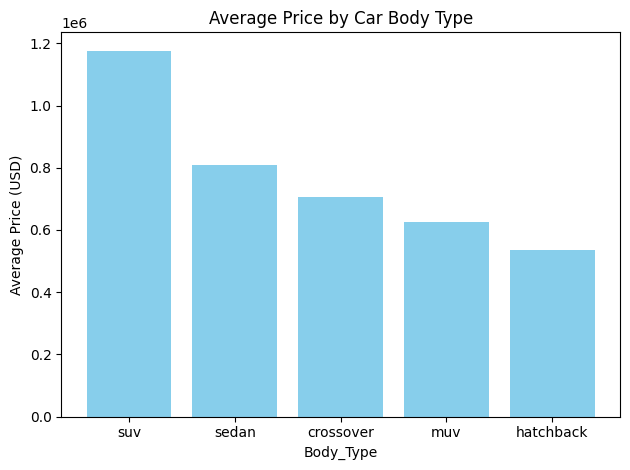

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv( "/workspace/labs/04_hedonic_pricing/cars_hw.csv" )

# Group by 'Model' and calculate the average price
average_prices_by_model = df.groupby('Body_Type')['Price'].mean().reset_index()

# Rename the columns for clarity
average_prices_by_model.columns = ['Body_Type', 'Average Price']

# Display the result
print(average_prices_by_model)

# Sort by average price for better visualization
average_prices_by_model = average_prices_by_model.sort_values(by='Average Price', ascending=False)

# Plotting the average prices by model
plt.bar(average_prices_by_model['Body_Type'], average_prices_by_model['Average Price'], color='skyblue')

# Adding labels and title
plt.xlabel('Body_Type')
plt.ylabel('Average Price (USD)')
plt.title('Average Price by Car Body Type')
plt.xticks(rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

# from the bar graph, we see that SUVs have the highest average price and hatchbacks have the lowest.

             Make  Average Price
0       Chevrolet   4.535000e+05
1          Datsun   2.896667e+05
2            Ford   7.211731e+05
3           Honda   7.989726e+05
4         Hyundai   6.918918e+05
5            Jeep   1.499500e+06
6             Kia   1.614750e+06
7       MG Motors   1.869457e+06
8        Mahindra   1.100167e+06
9   Maruti Suzuki   5.887850e+05
10         Nissan   8.842500e+05
11        Renault   6.625735e+05
12          Skoda   1.136000e+06
13           Tata   1.055217e+06
14         Toyota   8.003400e+05
15     Volkswagen   6.058276e+05


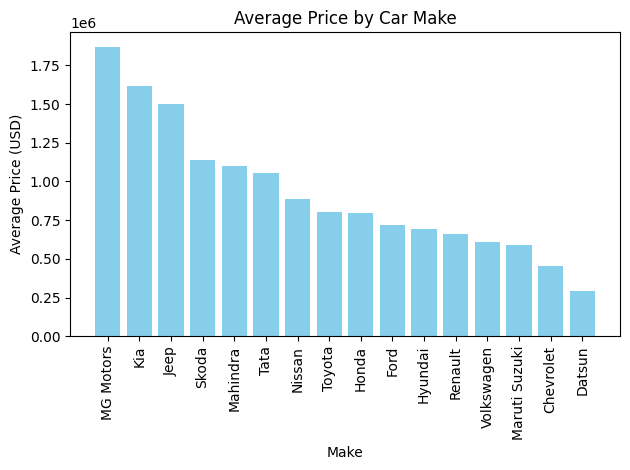

In [3]:
# price by car make

# Group by 'Model' and calculate the average price
average_prices_by_make = df.groupby('Make')['Price'].mean().reset_index()

# Rename the columns for clarity
average_prices_by_make.columns = ['Make', 'Average Price']

# Display the result
print(average_prices_by_make)

# Sort by average price for better visualization
average_prices_by_make = average_prices_by_make.sort_values(by='Average Price', ascending=False)

# Plotting the average prices by model
plt.bar(average_prices_by_make['Make'], average_prices_by_make['Average Price'], color='skyblue')

# Adding labels and title
plt.xlabel('Make')
plt.ylabel('Average Price (USD)')
plt.title('Average Price by Car Make')
plt.xticks(rotation=90)

# Show the plot
plt.tight_layout()
plt.show()

# MG Motors and Kia have the highest average car price, whereas Chevy and Datsun have the lowest.

2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.


In [4]:
# transform the "number of owners" variable to integer by removing letters
df['No_of_Owners'] = df['No_of_Owners'].str.replace(r'\D', '', regex=True)

3. Implement an ~80/~20 train-test split. Put the test data aside.


In [ ]:
# code modified from https://sparkbyexamples.com/pandas/pandas-create-test-and-train-samples-from-dataframe/ 

# Use train_test_split() Method.
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2)

4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?


5. Include transformations and interactions, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?


6. Summarize your results from 1 to 5. Have you learned anything about overfitting and underfitting, or model selection?



7. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.